In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from collections import Counter

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving text.txt to text.txt


In [ ]:
file = open("text.txt","r",encoding="utf8")

text = file.read()

file.close()

text = text.lower()

print(text[:500])

once upon a time there was a small village near a forest
the village was peaceful and the people lived happily
every morning the sun rose over the hills and the birds sang songs
children walked to school while farmers went to their fields
the village market opened early in the morning
people bought vegetables fruits and fresh bread
there lived a young boy named arun in the village
arun loved to explore the forest near his home
his grandmother often told him stories about the forest
she said the 


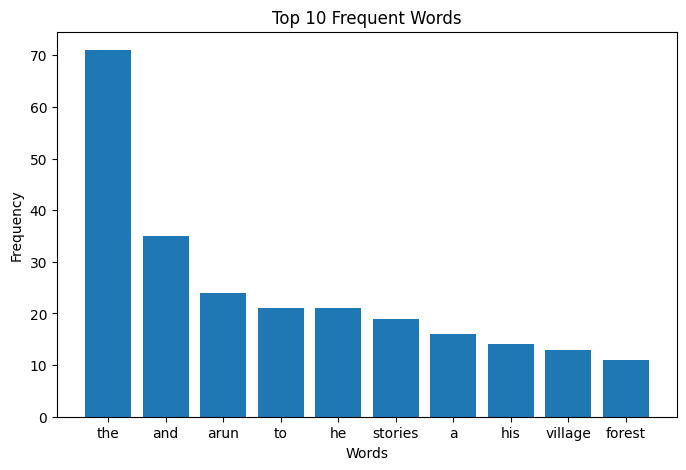

In [ ]:
words = text.split()

word_counts = Counter(words)

common_words = word_counts.most_common(10)

w = [i[0] for i in common_words]
c = [i[1] for i in common_words]

plt.figure(figsize=(8,5))
plt.bar(w,c)
plt.title("Top 10 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index

total_words = len(word_index) + 1

print("Total Vocabulary Size:", total_words)

Total Vocabulary Size: 275


In [ ]:
input_sequences = []

lines = text.split("\n")

for line in lines:

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1,len(token_list)):

        sequence = token_list[:i+1]

        input_sequences.append(sequence)

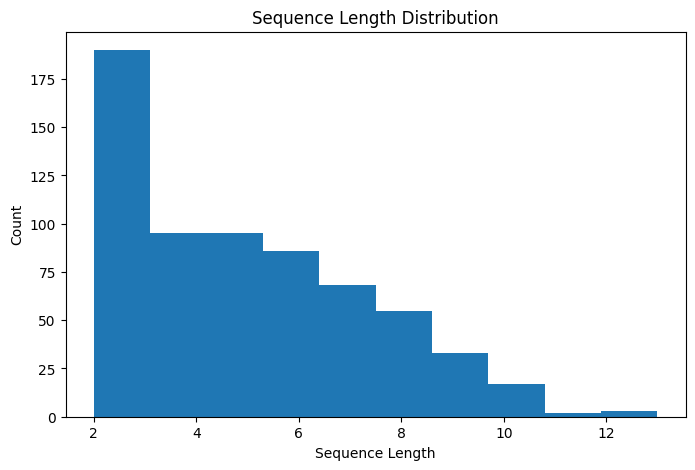

In [ ]:
sequence_lengths = [len(seq) for seq in input_sequences]

plt.figure(figsize=(8,5))
plt.hist(sequence_lengths,bins=10)
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()

In [ ]:
max_length = max(len(x) for x in input_sequences)

input_sequences = pad_sequences(input_sequences,
                                maxlen=max_length,
                                padding='pre')

print("Max Sequence Length:",max_length)

Max Sequence Length: 13


In [ ]:
X = input_sequences[:,:-1]

y = input_sequences[:,-1]

y = to_categorical(y,num_classes=total_words)

print("Input Shape:",X.shape)
print("Output Shape:",y.shape)

Input Shape: (644, 12)
Output Shape: (644, 275)


In [ ]:
rnn_model = Sequential()

rnn_model.add(Embedding(total_words,50,input_length=max_length-1))

rnn_model.add(SimpleRNN(100))

rnn_model.add(Dense(total_words,activation='softmax'))

rnn_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_history = rnn_model.fit(X,y,epochs=50,verbose=1)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0198 - loss: 5.5719
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0642 - loss: 5.1848
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0842 - loss: 5.0218
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0726 - loss: 5.0120
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0675 - loss: 4.9772
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0894 - loss: 4.8714
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0823 - loss: 4.8129
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0908 - loss: 4.7701
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1134 - loss: 4.6220
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1308 - loss: 4.5307
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1555 - loss: 4.4177
Epoch 12/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1518 - lo

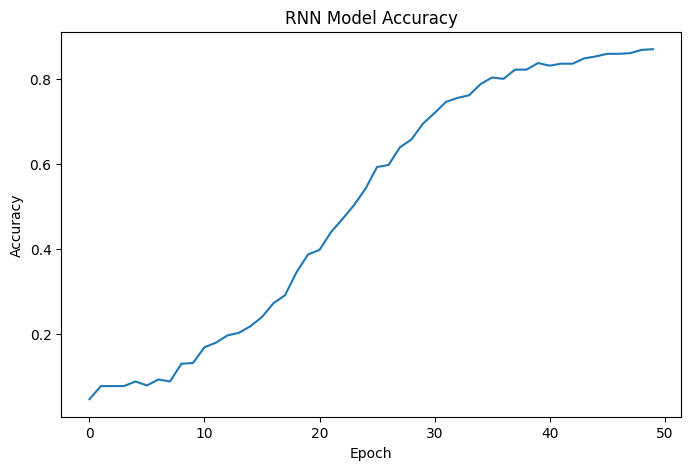

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history['accuracy'])
plt.title("RNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

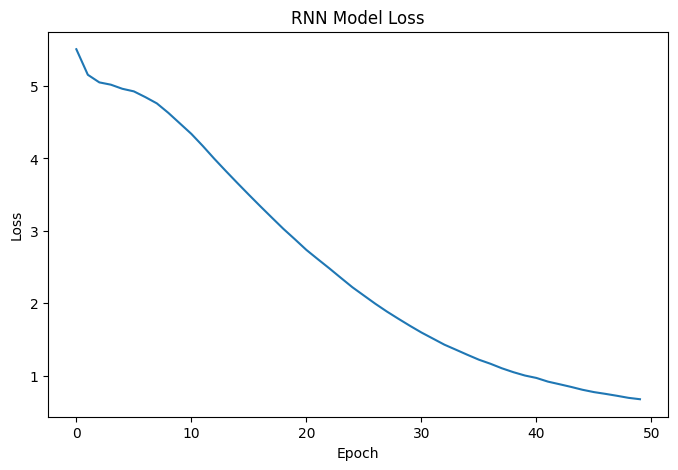

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history['loss'])
plt.title("RNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
lstm_model = Sequential()

lstm_model.add(Embedding(total_words,50,input_length=max_length-1))

lstm_model.add(LSTM(100))

lstm_model.add(Dense(total_words,activation='softmax'))

lstm_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(X,y,epochs=50,verbose=1)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0288 - loss: 5.6088
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0751 - loss: 5.2971
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0669 - loss: 5.1358
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0859 - loss: 4.9552
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0752 - loss: 5.0269
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0733 - loss: 4.9641
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0820 - loss: 4.9030
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0756 - loss: 4.9433
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0740 - loss: 4.9187
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0797 - loss: 4.8481
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0801 - loss: 4.8350
Epoch 12/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy:

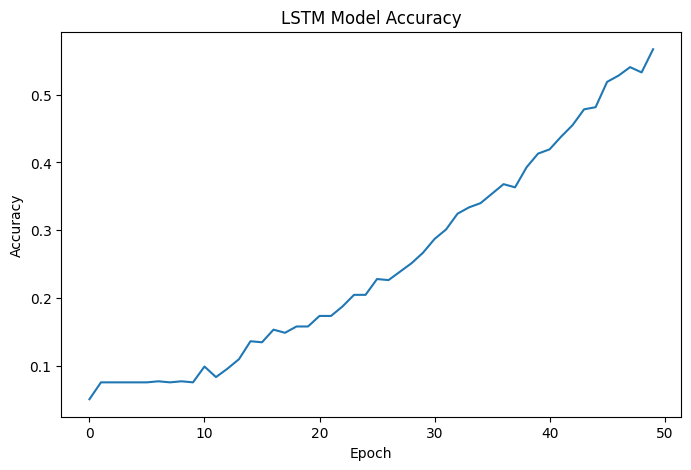

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history['accuracy'])
plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

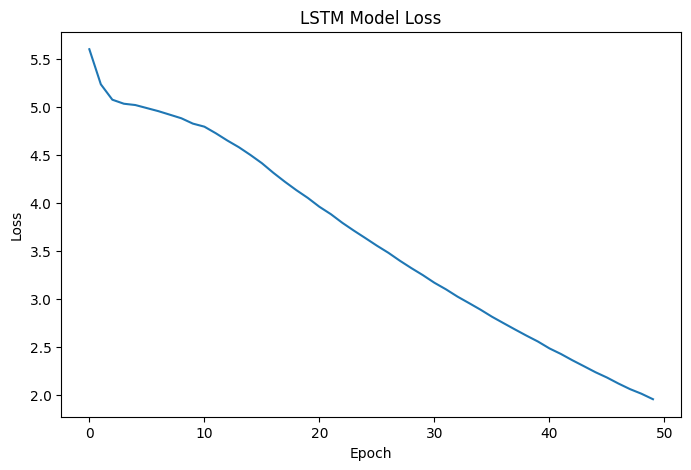

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history['loss'])
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
seed_text = "arun continued"

next_words = 10

for i in range(next_words):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences([token_list],
                               maxlen=max_length-1,
                               padding='pre')

    predicted = np.argmax(rnn_model.predict(token_list),axis=-1)

    for word,index in tokenizer.word_index.items():

        if index == predicted:

            seed_text = seed_text + " " + word

            break

print("Generated Text:")
print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Generated Text:
arun continued to explore the forest near a forest near his home


In [ ]:
seed_text = "arun continued"

next_words = 10

for i in range(next_words):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences([token_list],
                               maxlen=max_length-1,
                               padding='pre')

    predicted = np.argmax(lstm_model.predict(token_list),axis=-1)

    for word,index in tokenizer.word_index.items():

        if index == predicted:

            seed_text = seed_text + " " + word

            break

print("Generated Text:")
print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Generated Text:
arun continued to explore the forest and the forest swimming sang sang
